In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
import os

print(os.getcwd())
print(os.listdir(".."))

/Users/imseoyeong/Desktop/Project/digital-commerce-growth-analytics/notebooks
['.DS_Store', 'anaconda_projects', 'visualizations', '.virtual_documents', 'data', 'notebooks', 'sql']


In [20]:
print(os.listdir("../data"))

['.DS_Store', 'processed', 'raw']


In [21]:
print(os.listdir("../data/processed"))

['.DS_Store', 'ml_repeat_purchase_dataset.csv']


In [22]:
print(os.listdir("../data/processed"))

['.DS_Store', 'ml_repeat_purchase_dataset.csv']


In [23]:
df = pd.read_csv(
    "../data/processed/ml_repeat_purchase_dataset.csv",
    dtype={"user_pseudo_id": "string"},
    parse_dates=["first_order_date"]
)

df.head()

,user_pseudo_id,first_order_date,purchase_day_of_week,purchase_hour_utc,device_category,first_source,first_medium,first_order_revenue,first_order_items,sessions_before_first_purchase,product_views_before_purchase,add_to_cart_before_purchase,checkout_events_before_purchase,search_events_before_purchase,days_first_visit_to_purchase,repeat_purchase_30d
0,12485307.5806877734,2020-11-12,5,9,desktop,(data deleted),(data deleted),54.0,3,3,8,0,2,1,NaN,0
1,74159065.7287032878,2020-11-12,5,11,desktop,(data deleted),(data deleted),46.0,1,1,3,0,2,0,NaN,0
2,8204448.9073098218,2020-11-12,5,22,desktop,(data deleted),(data deleted),168.0,8,5,42,0,6,0,NaN,0
3,2794121.3808098678,2020-11-13,6,21,desktop,(data deleted),(data deleted),92.0,1,2,0,0,2,0,7.0,0
4,1874742.4444474598,2020-11-13,6,3,desktop,(data deleted),(data deleted),44.0,1,3,6,0,2,0,NaN,0


In [24]:
print(df.shape)
df.info()

(2815, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2815 entries, 0 to 2814
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   user_pseudo_id                   2815 non-null   string        
 1   first_order_date                 2815 non-null   datetime64[ns]
 2   purchase_day_of_week             2815 non-null   int64         
 3   purchase_hour_utc                2815 non-null   int64         
 4   device_category                  2815 non-null   object        
 5   first_source                     2815 non-null   object        
 6   first_medium                     2815 non-null   object        
 7   first_order_revenue              2815 non-null   float64       
 8   first_order_items                2815 non-null   int64         
 9   sessions_before_first_purchase   2815 non-null   int64         
 10  product_views_before_purchase    2815 non-null   

In [25]:
target_counts = df["repeat_purchase_30d"].value_counts().sort_index()
target_pct = df["repeat_purchase_30d"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct.round(2)
})

target_summary

,count,percent
repeat_purchase_30d,,
0,2460,87.39
1,355,12.61


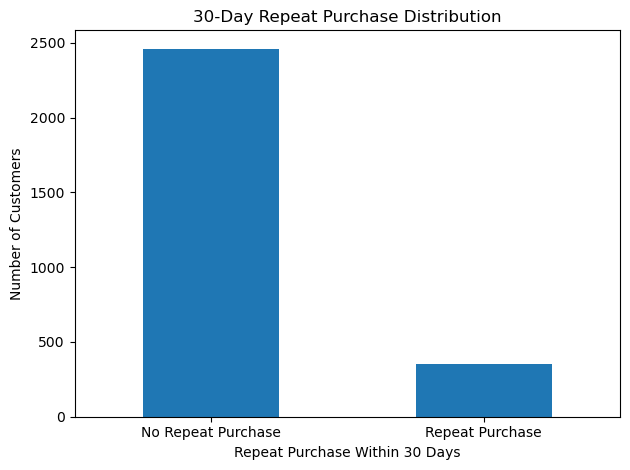

In [26]:
target_counts.plot(kind="bar")

plt.title("30-Day Repeat Purchase Distribution")
plt.xlabel("Repeat Purchase Within 30 Days")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No Repeat Purchase", "Repeat Purchase"], rotation=0)
plt.tight_layout()
plt.show()

In [27]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_percent
days_first_visit_to_purchase,605,21.49


In [28]:
df.groupby("repeat_purchase_30d")[
    [
        "first_order_revenue",
        "first_order_items",
        "sessions_before_first_purchase",
        "product_views_before_purchase",
        "add_to_cart_before_purchase",
        "checkout_events_before_purchase",
        "search_events_before_purchase"
    ]
].mean().round(2)

,first_order_revenue,first_order_items,sessions_before_first_purchase,product_views_before_purchase,add_to_cart_before_purchase,checkout_events_before_purchase,search_events_before_purchase
repeat_purchase_30d,,,,,,,
0,72.66,4.81,2.34,20.09,5.52,4.40,0.5
1,76.47,4.06,2.69,20.45,4.83,4.83,0.5


In [29]:
missing_by_target = pd.crosstab(
    df["repeat_purchase_30d"],
    df["days_first_visit_to_purchase"].isna(),
    normalize="index"
) * 100

In [30]:
df.groupby("repeat_purchase_30d")["days_first_visit_to_purchase"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
repeat_purchase_30d,,,
0,1956,3.46,0.0
1,254,4.08,0.0


In [31]:
device_summary = (
    df.groupby("device_category")
      .agg(
          customers=("user_pseudo_id", "count"),
          repeat_buyers=("repeat_purchase_30d", "sum"),
          repeat_purchase_rate=("repeat_purchase_30d", "mean")
      )
)

device_summary["repeat_purchase_rate"] = (
    device_summary["repeat_purchase_rate"] * 100
).round(2)

device_summary.sort_values("repeat_purchase_rate", ascending=False)

,customers,repeat_buyers,repeat_purchase_rate
device_category,,,
mobile,1150,152,13.22
desktop,1614,197,12.21
tablet,51,6,11.76


In [32]:
source_summary = (
    df.groupby(["first_source", "first_medium"])
      .agg(
          customers=("user_pseudo_id", "count"),
          repeat_buyers=("repeat_purchase_30d", "sum"),
          repeat_purchase_rate=("repeat_purchase_30d", "mean")
      )
      .reset_index()
)

source_summary["repeat_purchase_rate"] = (
    source_summary["repeat_purchase_rate"] * 100
).round(2)

source_summary.sort_values(
    ["repeat_purchase_rate", "customers"],
    ascending=[False, False]
)

,first_source,first_medium,customers,repeat_buyers,repeat_purchase_rate
8,shop.googlemerchandisestore.com,referral,335,52,15.52
0,(data deleted),(data deleted),400,58,14.50
2,<Other>,(data deleted),7,1,14.29
5,<Other>,referral,268,37,13.81
1,(direct),(none),622,80,12.86
3,<Other>,<Other>,295,34,11.53
7,google,organic,738,83,11.25
4,<Other>,organic,57,6,10.53
6,google,cpc,93,4,4.30


In [33]:
target = "repeat_purchase_30d"

features = [
    "purchase_day_of_week",
    "purchase_hour_utc",
    "device_category",
    "first_source",
    "first_medium",
    "first_order_revenue",
    "first_order_items",
    "sessions_before_first_purchase",
    "product_views_before_purchase",
    "add_to_cart_before_purchase",
    "checkout_events_before_purchase",
    "search_events_before_purchase",
    "days_first_visit_to_purchase"
]

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print(y.value_counts())

X shape: (2815, 13)
y shape: (2815,)

repeat_purchase_30d
0    2460
1     355
Name: count, dtype: int64


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (2252, 13)
Test set: (563, 13)

Training target distribution:
repeat_purchase_30d
0    0.874
1    0.126
Name: proportion, dtype: float64

Test target distribution:
repeat_purchase_30d
0    0.874
1    0.126
Name: proportion, dtype: float64


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "purchase_day_of_week",
    "purchase_hour_utc",
    "device_category",
    "first_source",
    "first_medium"
]

numeric_features = [
    "first_order_revenue",
    "first_order_items",
    "sessions_before_first_purchase",
    "product_views_before_purchase",
    "add_to_cart_before_purchase",
    "checkout_events_before_purchase",
    "search_events_before_purchase",
    "days_first_visit_to_purchase"
]

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Classification Report")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print(
    "PR-AUC:",
    round(average_precision_score(y_test, y_prob), 3)
)

Classification Report
              precision    recall  f1-score   support

           0      0.902     0.620     0.735       492
           1      0.169     0.535     0.257        71

    accuracy                          0.609       563
   macro avg      0.536     0.578     0.496       563
weighted avg      0.810     0.609     0.675       563

Confusion Matrix
[[305 187]
 [ 33  38]]

ROC-AUC: 0.596
PR-AUC: 0.182


In [37]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [38]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, digits=3))

print("Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nROC-AUC:", round(roc_auc_score(y_test, rf_prob), 3))
print(
    "PR-AUC:",
    round(average_precision_score(y_test, rf_prob), 3)
)

Random Forest Classification Report
              precision    recall  f1-score   support

           0      0.876     0.917     0.896       492
           1      0.146     0.099     0.118        71

    accuracy                          0.813       563
   macro avg      0.511     0.508     0.507       563
weighted avg      0.784     0.813     0.798       563

Confusion Matrix
[[451  41]
 [ 64   7]]

ROC-AUC: 0.532
PR-AUC: 0.139


In [39]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob)
    ]
})

model_comparison.round(3)

,Model,ROC_AUC,PR_AUC
0,Logistic Regression,0.596,0.182
1,Random Forest,0.532,0.139


In [40]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

,feature,coefficient,abs_coefficient
29,cat__purchase_hour_utc_13,-0.819766,0.819766
25,cat__purchase_hour_utc_9,0.654481,0.654481
20,cat__purchase_hour_utc_4,-0.496923,0.496923
51,cat__first_medium_cpc,-0.476624,0.476624
34,cat__purchase_hour_utc_18,0.427768,0.427768
27,cat__purchase_hour_utc_11,0.419650,0.419650
22,cat__purchase_hour_utc_6,-0.409053,0.409053
39,cat__purchase_hour_utc_23,-0.406966,0.406966
36,cat__purchase_hour_utc_20,-0.392125,0.392125
33,cat__purchase_hour_utc_17,0.391694,0.391694


In [41]:
print("Top positive coefficients")
display(
    coef_df.sort_values("coefficient", ascending=False)
    [["feature", "coefficient"]]
    .head(10)
)

print("Top negative coefficients")
display(
    coef_df.sort_values("coefficient")
    [["feature", "coefficient"]]
    .head(10)
)

Top positive coefficients


,feature,coefficient
25,cat__purchase_hour_utc_9,0.654481
34,cat__purchase_hour_utc_18,0.427768
27,cat__purchase_hour_utc_11,0.419650
33,cat__purchase_hour_utc_17,0.391694
28,cat__purchase_hour_utc_12,0.309141
14,cat__purchase_day_of_week_6,0.257495
26,cat__purchase_hour_utc_10,0.255164
53,cat__first_medium_referral,0.212803
0,num__first_order_revenue,0.183106
8,num__missingindicator_days_first_visit_to_purc...,0.157665


Top negative coefficients


,feature,coefficient
29,cat__purchase_hour_utc_13,-0.819766
20,cat__purchase_hour_utc_4,-0.496923
51,cat__first_medium_cpc,-0.476624
22,cat__purchase_hour_utc_6,-0.409053
39,cat__purchase_hour_utc_23,-0.406966
36,cat__purchase_hour_utc_20,-0.392125
30,cat__purchase_hour_utc_14,-0.315888
19,cat__purchase_hour_utc_3,-0.299865
1,num__first_order_items,-0.295816
46,cat__first_source_google,-0.288606


In [42]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

permutation_df.round(4)

,feature,importance,std
1,purchase_hour_utc,0.0204,0.0183
7,sessions_before_first_purchase,0.0167,0.0072
10,checkout_events_before_purchase,0.0151,0.0062
5,first_order_revenue,0.0103,0.0107
6,first_order_items,0.0076,0.0051
0,purchase_day_of_week,0.0061,0.0089
2,device_category,0.0056,0.0047
4,first_medium,0.0042,0.0093
9,add_to_cart_before_purchase,0.0038,0.0020
11,search_events_before_purchase,-0.0008,0.0006


In [43]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

threshold_df["f1"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    / (
        threshold_df["precision"]
        + threshold_df["recall"]
    )
)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10).round(3)

,threshold,precision,recall,f1
363,0.519,0.185,0.521,0.273
362,0.517,0.184,0.521,0.272
369,0.523,0.186,0.507,0.272
361,0.517,0.183,0.521,0.271
368,0.522,0.185,0.507,0.271
353,0.513,0.181,0.535,0.270
360,0.517,0.182,0.521,0.270
367,0.522,0.184,0.507,0.270
352,0.513,0.180,0.535,0.270
359,0.517,0.181,0.521,0.269


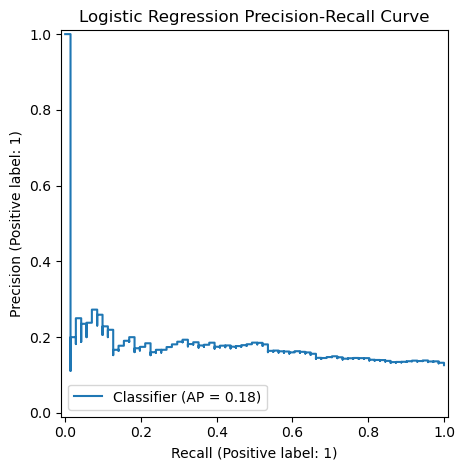

In [44]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression Precision-Recall Curve")
plt.tight_layout()

plt.savefig(
    "../visualizations/repeat_purchase_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

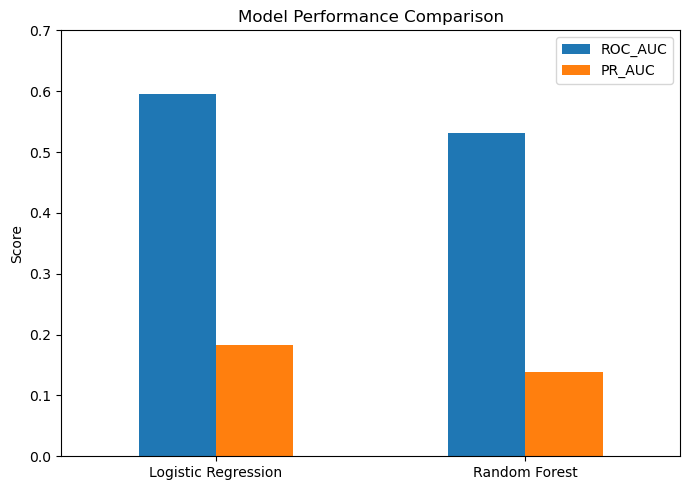

In [45]:
model_plot_df = model_comparison.set_index("Model")

model_plot_df.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)
plt.tight_layout()

plt.savefig(
    "../visualizations/repeat_purchase_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

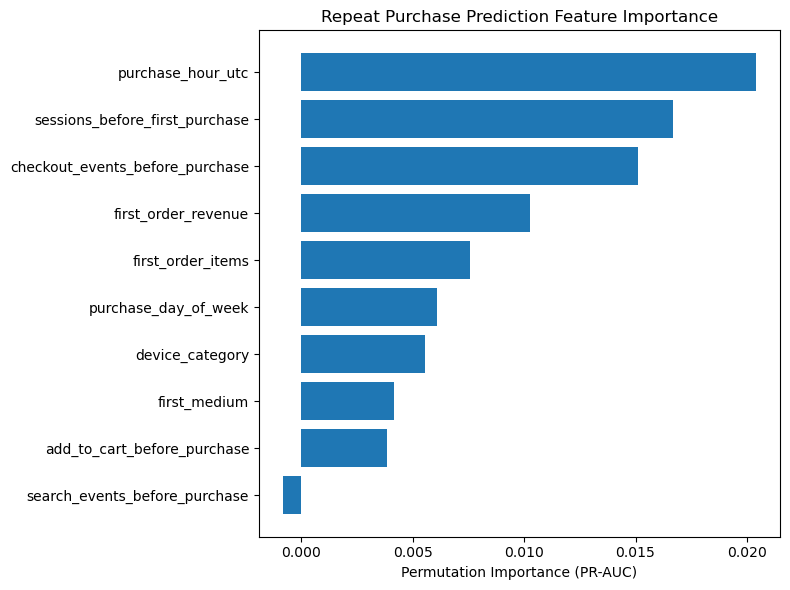

In [46]:
top_features = (
    permutation_df
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Permutation Importance (PR-AUC)")
plt.ylabel("")
plt.title("Repeat Purchase Prediction Feature Importance")
plt.tight_layout()

plt.savefig(
    "../visualizations/repeat_purchase_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
# Save model evaluation tables

model_comparison.round(4).to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

permutation_df.round(4).to_csv(
    "../data/processed/permutation_importance.csv",
    index=False
)

coef_df.round(4).to_csv(
    "../data/processed/logistic_regression_coefficients.csv",
    index=False
)

print("Model results saved successfully.")

Model results saved successfully.


## Conclusion

This analysis evaluated whether first-purchase behavior and acquisition characteristics could help predict whether a customer would make another purchase within 30 days.

### Key Findings

- The dataset included 2,815 first-time purchasers, of whom 355 (12.61%) made a repeat purchase within 30 days.
- Logistic Regression outperformed Random Forest on both ROC-AUC and PR-AUC.
  - Logistic Regression: ROC-AUC = 0.596, PR-AUC = 0.182
  - Random Forest: ROC-AUC = 0.532, PR-AUC = 0.139
- The strongest predictive signals included purchase timing, sessions before the first purchase, checkout activity, first-order revenue, and first-order item count.
- Referral traffic showed a positive association with repeat purchasing, while CPC traffic showed a negative association in the Logistic Regression model.
- Adjusting the classification threshold provided only a small improvement in F1 score, indicating that threshold tuning alone could not substantially improve predictive performance.

### Interpretation

The available first-purchase and pre-purchase behavioral features contain some signal related to short-term customer retention, but they are not sufficient for highly accurate repeat-purchase prediction.

The relatively weak predictive performance suggests that stronger retention models would likely benefit from additional information such as product-level purchase history, customer engagement after purchase, promotional exposure, geographic information, and longer-term behavioral data.

### Modeling Decision

Logistic Regression was retained as the preferred baseline model because it generalized better than Random Forest and provided greater interpretability for understanding the direction of customer-level predictors.

Model results should be interpreted as predictive associations rather than causal effects.